In [1]:
#%matplotlib notebook
import numpy  as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
q = 1.60217662E-19  #elementary charge C
m = 9.10938356E-31 # electron mass kg
pi = np.pi

def bfield_from_ECR(frequency):
    B_field = (1E9*2*pi*m*frequency)/q
    return B_field

def freq_from_bfield(B):
    freq = (q*B)/(1E9*2*pi*m)
    return freq

def format_plot(xlabel,ylabel, title):
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel(xlabel,fontsize=20)
    plt.ylabel(ylabel,fontsize=20)
    plt.title(title, fontsize = 22)
    plt.ticklabel_format(useOffset=False)
    #plt.legend(fontsize = 16)

## Magnet Configuration

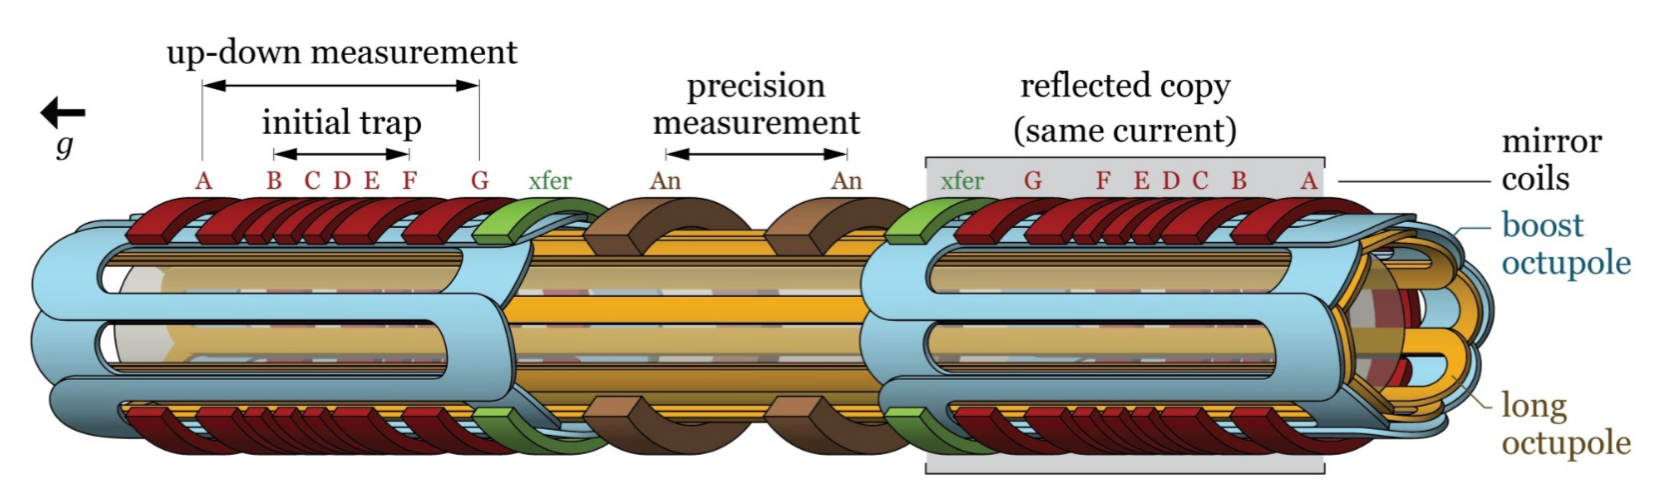



## 2D Model 

In [3]:
#some of the files are in the original folder but I made a new one for the magnets I added
path1 = 'Bfield_calculator_outputs/'
path2 = 'Bfield_calculator_outputs/Top Magnets/'

filename = path1 + "Babcock_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Position = np.array(data[:,0])*10
Position = [p + 671-342.5+1 for p in Position] #matches positions to sequencer
Babcock_2D = np.array(data[:,1]) 


filename = path1 + "Babcock_shim_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Babcock_2D_shim = np.array(data[:,1]) 


filename = path1 + "MAGB_1A" #MaB in series with MgB
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
MirA_2D = np.array(data[:,1])


filename = path1 + "SOB_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
SoB_2D = np.array(data[:,1])


filename = path1 + "LOCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
LoC_2D = np.array(data[:,1])


filename = path1 + "OCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Oc_2D = np.array(data[:,1])

filename = path2 + "tickle"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
tickle = np.array(data[:,1])

filename = path2 + 'MB_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_B = np.array(data[:,1])

filename = path2 + 'MC_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_C = np.array(data[:,1])

filename = path2 + 'MD_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_D = np.array(data[:,1])

filename = path2 + 'ME_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_E = np.array(data[:,1])

filename = path2 + 'MF_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_F = np.array(data[:,1])

filename = path2 + 'MA_T_1A'  #MaT in series with MgT
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_AT = np.array(data[:,1])

filename = path2 + 'MbT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_bT = np.array(data[:,1])

filename = path2 + 'McT'  
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_cT = np.array(data[:,1])

filename = path2 + 'MdT'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_dT = np.array(data[:,1])

filename = path2 + 'MeT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_eT = np.array(data[:,1])*2

filename = path2 + 'MfT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_fT = np.array(data[:,1])

filename = path2 + 'OcT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Octupole_B = np.array(data[:,1])

#this will calculate the B field given some currents
def field_2D_calculation(current):
    return Babcock_2D*current[0] + MirA_2D*current[1]  + SoB_2D*current[2] + LoC_2D*current[3] + Oc_2D*current[4] + tickle*current[5] + Babcock_2D_shim*current[6] + Mirror_B*current[7] + Mirror_C*current[8] + Mirror_D*current[9] + Mirror_E*current[10] + Mirror_F*current[11] + Mirror_AT*current[12] + Mirror_bT*current[13] + Mirror_cT*current[14] + Mirror_dT*current[15] + Mirror_eT*current[16] + Mirror_fT*current[17] + Octupole_B*current[18]


In [4]:
#magnet currents
B = 191 
BS = 5
MA = 70 #in series with MG
tickle_g = 0 
LOc = 830
Oc = 830
SB = 0


MB = 0 
MF = 0 

MC = 0
MD = 0 
ME = 0 


MAT = 0 #in series with MGT
MbT = 0
McT = 0
MdT = 0
MeT = 0
MfT = 0

OcT = 0


currents = [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 70, MbT, McT, MdT, MeT, MfT, OcT]
currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)


## Plotting

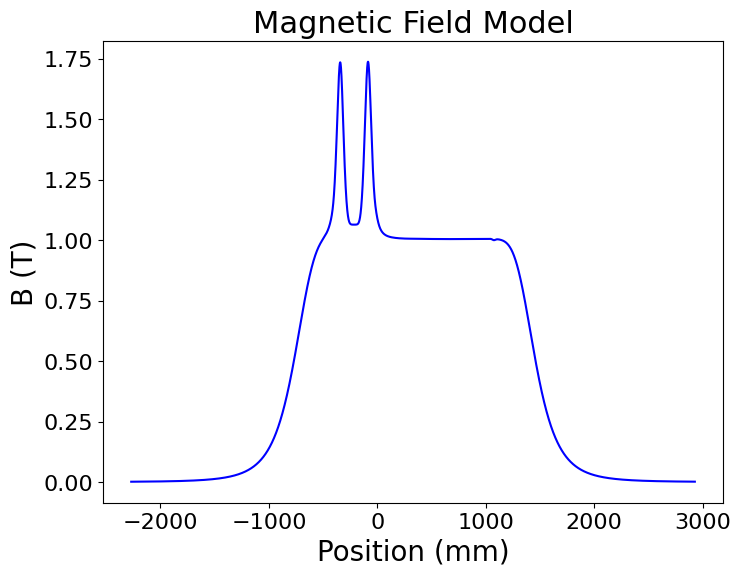

In [5]:
plt.figure(figsize=(8,6))

plt.plot([p for p in Position], field_2D/1e4, 'b', label = 'Field Model')

format_plot('Position (mm)', 'B (T)', 'Magnetic Field Model')

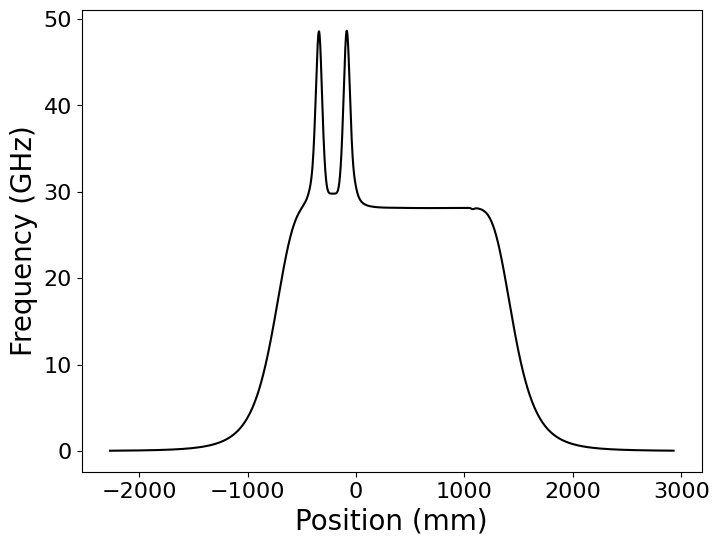

In [6]:
plt.figure(figsize = (8,6))

plt.plot(Position, [freq_from_bfield(b/1e4) for b in field_2D], color = 'k', label = 'Field Model')

format_plot('Position (mm)', 'Frequency (GHz)', '')

